# Shock-weighted XGBoost + Quantile Intervals for CPI MoM Inflation

Notebook sạch cho hướng xử lý **shock-aware forecasting**:

- Mô hình chính: **Shock-weighted XGBoost**.
- Mục tiêu: cải thiện khả năng học các tháng CPI có biến động bất thường.
- Khoảng dự báo: **Quantile intervals** bằng `HistGradientBoostingRegressor(loss="quantile")`.
- Đánh dấu shock kinh tế trên biểu đồ:
  - Statistical shock: dựa trên rolling z-score của CPI MoM.
  - Event windows: COVID, reopening/commodity shock, Ukraine-war commodity shock.

Lưu ý: mô hình này không ép R² đạt một mức cụ thể. Mục tiêu là đánh giá xem tăng trọng số cho shock và dự báo khoảng có cải thiện khả năng xử lý shock hay không.

In [1]:
import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf

from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    print("xgboost is not installed. Please install xgboost to run the main model.")

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False
    print("shap is not installed. SHAP analysis will be skipped.")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Compatibility fix for NumPy 2.x + older statsmodels
if not hasattr(np, "matrix"):
    np.matrix = np.ndarray

DATA_DIR = os.path.join(os.getcwd(), "data", "processed")
OUTPUT_DIR = os.path.join(os.getcwd(), "outputs", "step7_shock_weighted_xgb_quantile")
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_TAG = "shock_weighted_xgb_quantile"

print("Data:", DATA_DIR)
print("Output:", OUTPUT_DIR)

Data: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\data\processed
Output: d:\Nam4-HK1\KLTN\Vietnam_economic_lakehouse\model_test\outputs\step7_shock_weighted_xgb_quantile


In [2]:
# Load data
DATA_FILE = os.path.join(DATA_DIR, "cpi_forecast_selected_variables.csv")
raw = pd.read_csv(DATA_FILE)

if "date" in raw.columns:
    raw["date"] = pd.to_datetime(raw["date"])
    df_raw = raw.sort_values("date").set_index("date")
else:
    df_raw = pd.read_csv(DATA_FILE, index_col=0, parse_dates=True).sort_index()

target_var = "cpi_mom_inflation"
exog_vars = [c for c in df_raw.columns if c != target_var]

df_raw = df_raw[[target_var] + exog_vars].copy().dropna()

print("Shape:", df_raw.shape)
print("Period:", df_raw.index.min().date(), "to", df_raw.index.max().date())
print("Missing:", df_raw.isnull().sum().sum())
print("Target:", target_var)
print("Exogenous variables:", exog_vars)

Shape: (360, 9)
Period: 1995-01-01 to 2024-12-01
Missing: 0
Target: cpi_mom_inflation
Exogenous variables: ['broad_money', 'ppi_qoq', 'wti', 'gold', 'policy_rate', 'VNINDEX', 'NIKKEI225', 'USDVND']


In [3]:
# Stationarity-safe transformation for exogenous variables.
# Target CPI MoM inflation is kept in level form.

def safe_stationarity_classification(series):
    s = pd.Series(series).dropna()
    s = pd.to_numeric(s, errors="coerce").dropna()

    if len(s) < 30 or s.nunique() <= 1:
        return "I(0)", np.nan, np.nan

    try:
        adf_p = adfuller(s, autolag="AIC", regression="c")[1]
    except Exception:
        adf_p = 1.0

    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = 0.01

    status = "I(0)" if (adf_p < 0.05 and kpss_p > 0.05) else "I(1)"
    return status, adf_p, kpss_p

transformed = {target_var: df_raw[target_var]}
stationarity_report = []

for col in exog_vars:
    status, adf_p, kpss_p = safe_stationarity_classification(df_raw[col])

    if status == "I(0)":
        new_col = col
        transformed[new_col] = df_raw[col]
        method = "level"
    else:
        if (df_raw[col] > 0).all():
            new_col = f"dlog_{col}"
            transformed[new_col] = np.log(df_raw[col]).diff()
            method = "log_diff"
        else:
            new_col = f"diff_{col}"
            transformed[new_col] = df_raw[col].diff()
            method = "diff"

    stationarity_report.append({
        "variable": col,
        "status": status,
        "adf_p": adf_p,
        "kpss_p": kpss_p,
        "method": method,
        "new_col": new_col
    })

df = pd.DataFrame(transformed, index=df_raw.index).dropna()
exog_transformed = [c for c in df.columns if c != target_var]
stationarity_df = pd.DataFrame(stationarity_report)

print("Transformed data shape:", df.shape)
print(stationarity_df)

Transformed data shape: (359, 9)
      variable status     adf_p  kpss_p    method           new_col
0  broad_money   I(1)  0.280602    0.01  log_diff  dlog_broad_money
1      ppi_qoq   I(1)  0.307828    0.01      diff      diff_ppi_qoq
2          wti   I(1)  0.121689    0.01  log_diff          dlog_wti
3         gold   I(1)  0.989363    0.01  log_diff         dlog_gold
4  policy_rate   I(1)  0.121117    0.01  log_diff  dlog_policy_rate
5      VNINDEX   I(1)  0.721155    0.01  log_diff      dlog_VNINDEX
6    NIKKEI225   I(1)  0.991552    0.01  log_diff    dlog_NIKKEI225
7       USDVND   I(1)  0.786262    0.01  log_diff       dlog_USDVND


C:\Users\HP\AppData\Local\Temp\ipykernel_19596\3626026806.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_19596\3626026806.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_19596\3626026806.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s, regression="c", nlags="auto")[1]
C:\Users\HP\AppData\Local\Temp\ipykernel_19596\3626026806.py:17: InterpolationWarning: The test statistic is outside of the range of p-values availa

In [4]:
# Economic event windows and statistical shock labels.
# Event windows are used as additional features and for marking the plot.

def add_event_features(index):
    event = pd.DataFrame(index=index)

    # Major economic stress windows, encoded as deterministic calendar/event indicators.
    event["gfc_2008_2011"] = ((index >= "2008-01-01") & (index <= "2011-12-01")).astype(float)
    event["covid_period"] = ((index >= "2020-03-01") & (index <= "2021-12-01")).astype(float)
    event["reopening_commodity_2022"] = ((index >= "2022-01-01") & (index <= "2022-12-01")).astype(float)
    event["ukraine_war_commodity"] = ((index >= "2022-02-01") & (index <= "2023-12-01")).astype(float)

    # CPI-related seasonal/event proxies
    event["tet_window"] = pd.Index(index.month).isin([1, 2]).astype(float)
    event["school_fee_window"] = pd.Index(index.month).isin([8, 9, 10]).astype(float)
    event["year_end_window"] = pd.Index(index.month).isin([11, 12]).astype(float)

    return event


def add_statistical_shock_labels(data, target_col, z_threshold=1.5):
    out = data.copy()
    y = out[target_col]

    # Past-only rolling reference
    roll_mean = y.rolling(12).mean().shift(1)
    roll_std = y.rolling(12).std().shift(1)

    out["inflation_zscore_12"] = (y - roll_mean) / roll_std
    out["stat_shock"] = (out["inflation_zscore_12"].abs() > z_threshold).astype(float)
    out["positive_stat_shock"] = (out["inflation_zscore_12"] > z_threshold).astype(float)
    out["negative_stat_shock"] = (out["inflation_zscore_12"] < -z_threshold).astype(float)

    return out

df_labeled = add_statistical_shock_labels(df, target_var, z_threshold=1.5)
event_df = add_event_features(df_labeled.index)
df_labeled = pd.concat([df_labeled, event_df], axis=1)

shock_cols = ["stat_shock", "positive_stat_shock", "negative_stat_shock"]
event_cols = event_df.columns.tolist()

print("Shock/event labels created")
print("Statistical shocks:", int(df_labeled["stat_shock"].sum()))
print("Event columns:", event_cols)
print(df_labeled[[target_var, "inflation_zscore_12", "stat_shock", "positive_stat_shock", "negative_stat_shock"]].dropna().tail())

Shock/event labels created
Statistical shocks: 55
Event columns: ['gfc_2008_2011', 'covid_period', 'reopening_commodity_2022', 'ukraine_war_commodity', 'tet_window', 'school_fee_window', 'year_end_window']
            cpi_mom_inflation  inflation_zscore_12  stat_shock  \
date                                                             
2024-08-01          -0.477707            -0.866844         0.0   
2024-09-01           0.290000             0.517197         0.0   
2024-10-01           0.039884             0.095630         0.0   
2024-11-01          -0.199342            -0.497559         0.0   
2024-12-01           0.159792             0.229722         0.0   

            positive_stat_shock  negative_stat_shock  
date                                                  
2024-08-01                  0.0                  0.0  
2024-09-01                  0.0                  0.0  
2024-10-01                  0.0                  0.0  
2024-11-01                  0.0                  0.0  
2

In [5]:
# Tree feature engineering with shock-aware features.

def create_shock_weighted_features(data, target_col, exog_cols, max_target_lag=24, use_current_exog=True):
    X = pd.DataFrame(index=data.index)
    y = data[target_col].copy()

    if use_current_exog:
        for col in exog_cols:
            X[col] = data[col]

    # Target lags
    for lag in range(1, max_target_lag + 1):
        X[f"{target_col}_lag{lag}"] = y.shift(lag)

    # Exogenous lag/rolling features
    for col in exog_cols:
        for lag in [1, 2, 3, 6, 12]:
            X[f"{col}_lag{lag}"] = data[col].shift(lag)
        for window in [3, 6, 12]:
            X[f"{col}_roll_mean_{window}"] = data[col].rolling(window).mean().shift(1)
            X[f"{col}_roll_std_{window}"] = data[col].rolling(window).std().shift(1)

        # Exogenous shock indicators from past values
        abs_lag1 = data[col].shift(1).abs()
        threshold = abs_lag1.rolling(24, min_periods=12).quantile(0.85)
        X[f"{col}_abs_lag1"] = abs_lag1
        X[f"{col}_shock_lag1"] = (abs_lag1 > threshold).astype(float)

    # Target rolling statistics, shifted to avoid leakage
    for window in [3, 6, 12]:
        X[f"{target_col}_roll_mean_{window}"] = y.rolling(window).mean().shift(1)
        X[f"{target_col}_roll_std_{window}"] = y.rolling(window).std().shift(1)
        X[f"{target_col}_roll_min_{window}"] = y.rolling(window).min().shift(1)
        X[f"{target_col}_roll_max_{window}"] = y.rolling(window).max().shift(1)

    # Past-only shock score features
    roll_mean_12 = y.rolling(12).mean().shift(1)
    roll_std_12 = y.rolling(12).std().shift(1)
    X[f"{target_col}_past_zscore_12"] = (y.shift(1) - roll_mean_12) / roll_std_12
    X["past_positive_inflation_shock"] = (X[f"{target_col}_past_zscore_12"] > 1.5).astype(float)
    X["past_negative_inflation_shock"] = (X[f"{target_col}_past_zscore_12"] < -1.5).astype(float)
    X["past_abs_inflation_shock"] = X[f"{target_col}_past_zscore_12"].abs()

    # Seasonality and event windows
    month = data.index.month
    X["month_sin"] = np.sin(2 * np.pi * month / 12)
    X["month_cos"] = np.cos(2 * np.pi * month / 12)
    X["quarter_sin"] = np.sin(2 * np.pi * data.index.quarter / 4)
    X["quarter_cos"] = np.cos(2 * np.pi * data.index.quarter / 4)
    X["is_jan"] = (month == 1).astype(float)
    X["is_feb"] = (month == 2).astype(float)
    X["is_sep"] = (month == 9).astype(float)
    X["is_dec"] = (month == 12).astype(float)

    # Event windows from deterministic calendar indicators
    event_features = add_event_features(data.index)
    X = pd.concat([X, event_features], axis=1)

    # Regime feature
    X["inflation_volatility_12m"] = y.rolling(12).std().shift(1)
    high_vol_threshold = X["inflation_volatility_12m"].quantile(0.75)
    X["high_vol_regime"] = (X["inflation_volatility_12m"] > high_vol_threshold).astype(float)

    # Interaction features
    key_exog = [c for c in exog_cols if any(k in c.lower() for k in ["wti", "gold", "usdvnd", "money", "policy"])]
    for col in key_exog[:5]:
        if f"{col}_lag1" in X.columns:
            X[f"lag1_x_{col}_lag1"] = X[f"{target_col}_lag1"] * X[f"{col}_lag1"]
            X[f"vol_x_{col}_lag1"] = X["inflation_volatility_12m"] * X[f"{col}_lag1"]

    # Labels used only for weighting/diagnostics, not model features at time t.
    label_cols = ["stat_shock", "positive_stat_shock", "negative_stat_shock", "inflation_zscore_12"]
    labels = data[label_cols].copy()

    feature_df = pd.concat([X, y.rename(target_col), labels], axis=1).dropna()
    X_final = feature_df.drop(columns=[target_col] + label_cols)
    y_final = feature_df[target_col]
    labels_final = feature_df[label_cols]

    return X_final, y_final, labels_final, high_vol_threshold

USE_CURRENT_EXOG = True
X, y, labels, high_vol_threshold = create_shock_weighted_features(
    df_labeled,
    target_var,
    exog_transformed,
    max_target_lag=24,
    use_current_exog=USE_CURRENT_EXOG
)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Labels shape:", labels.shape)
print("Feature period:", X.index.min().date(), "to", X.index.max().date())
print("High-vol threshold:", round(high_vol_threshold, 6))
print("Shock count in supervised data:", int(labels["stat_shock"].sum()))

Feature matrix shape: (335, 179)
Target shape: (335,)
Labels shape: (335, 4)
Feature period: 1997-02-01 to 2024-12-01
High-vol threshold: 0.955502
Shock count in supervised data: 55


In [6]:
# Chronological split
n_total = len(X)
train_end = int(0.80 * n_total)
val_end = int(0.90 * n_total)

X_train, y_train, labels_train = X.iloc[:train_end], y.iloc[:train_end], labels.iloc[:train_end]
X_val, y_val, labels_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end], labels.iloc[train_end:val_end]
X_test, y_test, labels_test = X.iloc[val_end:], y.iloc[val_end:], labels.iloc[val_end:]

X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])
labels_train_full = pd.concat([labels_train, labels_val])

print("Chronological split")
print(f"Train: {X_train.shape}, {X_train.index.min().date()} to {X_train.index.max().date()}, shocks={int(labels_train['stat_shock'].sum())}")
print(f"Val:   {X_val.shape}, {X_val.index.min().date()} to {X_val.index.max().date()}, shocks={int(labels_val['stat_shock'].sum())}")
print(f"Test:  {X_test.shape}, {X_test.index.min().date()} to {X_test.index.max().date()}, shocks={int(labels_test['stat_shock'].sum())}")

Chronological split
Train: (268, 179), 1997-02-01 to 2019-05-01, shocks=45
Val:   (33, 179), 2019-06-01 to 2022-02-01, shocks=6
Test:  (34, 179), 2022-03-01 to 2024-12-01, shocks=4


Running SHAP feature selection...
Selected top 40 SHAP features
                       feature  importance
                     month_sin    0.255359
                      dlog_wti    0.054558
         dlog_broad_money_lag3    0.052994
       cpi_mom_inflation_lag24    0.050525
 cpi_mom_inflation_roll_mean_3    0.045958
       cpi_mom_inflation_lag12    0.043375
 cpi_mom_inflation_roll_mean_6    0.035551
          dlog_USDVND_abs_lag1    0.034645
                    tet_window    0.031968
 cpi_mom_inflation_roll_std_12    0.028767
        dlog_broad_money_lag12    0.027681
          dlog_gold_roll_std_6    0.027427
                     dlog_gold    0.026133
       dlog_VNINDEX_roll_std_3    0.019787
       lag1_x_dlog_USDVND_lag1    0.019400
cpi_mom_inflation_roll_mean_12    0.017212
        cpi_mom_inflation_lag6    0.016603
        cpi_mom_inflation_lag2    0.015153
      dlog_USDVND_roll_mean_12    0.013226
       cpi_mom_inflation_lag19    0.012719
                  dlog_VNINDEX   

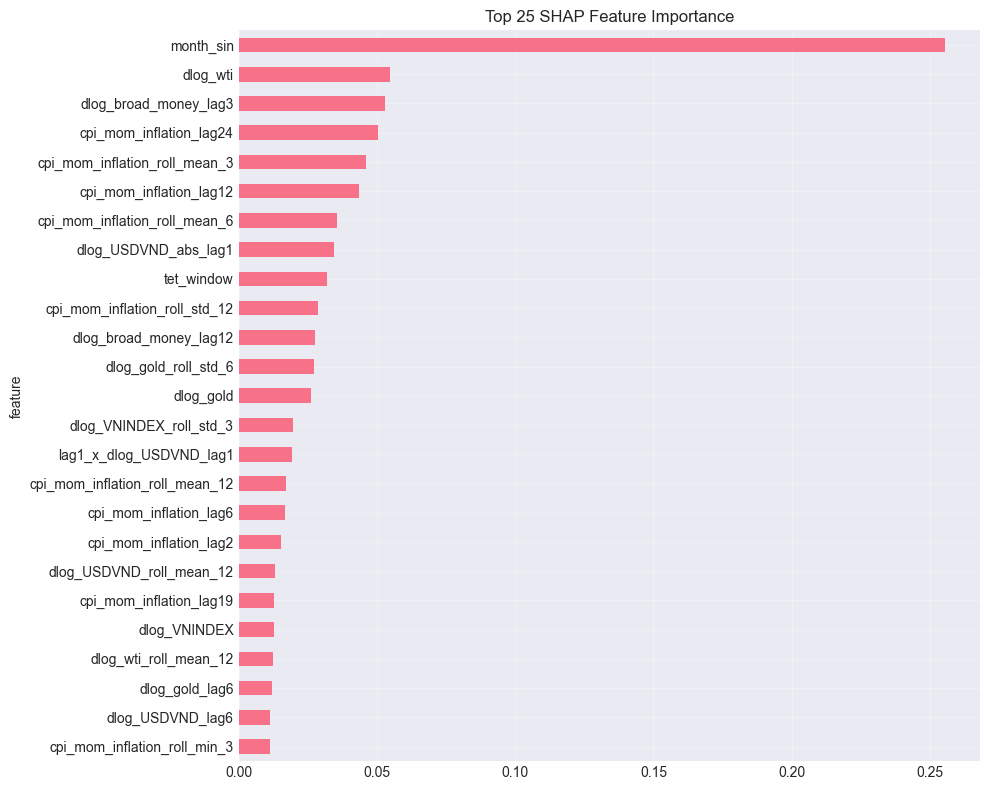

Selected feature count: 40


In [7]:
# SHAP feature selection is optional.
USE_SHAP_SELECTION = HAS_SHAP and HAS_XGB
TOP_N = 40

if USE_SHAP_SELECTION:
    print("Running SHAP feature selection...")
    xgb_for_shap = XGBRegressor(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    )
    # Basic shock weighting for SHAP pre-model
    shap_weights = 1.0 + 2.0 * labels_train["stat_shock"].values
    xgb_for_shap.fit(X_train, y_train, sample_weight=shap_weights, verbose=False)

    explainer = shap.TreeExplainer(xgb_for_shap)
    shap_values = explainer.shap_values(X_val)
    shap_importance = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({"feature": X_train.columns, "importance": shap_importance}).sort_values("importance", ascending=False)
    selected_features = shap_df.head(TOP_N)["feature"].tolist()

    print(f"Selected top {TOP_N} SHAP features")
    print(shap_df.head(TOP_N).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    shap_df.head(25).iloc[::-1].plot(x="feature", y="importance", kind="barh", ax=ax, legend=False)
    ax.set_title("Top 25 SHAP Feature Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "shock_weighted_shap_feature_importance.png"), dpi=150)
    plt.show()
else:
    selected_features = X_train.columns.tolist()
    print("SHAP selection skipped. Using all features:", len(selected_features))

X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]
X_test_sel = X_test[selected_features]
X_train_full_sel = X_train_full[selected_features]

print("Selected feature count:", len(selected_features))

In [8]:
# Sample weights for shock-aware training.
# Shock observations receive larger weights. High-volatility regimes receive moderate additional weight.

def build_sample_weights(labels, base_weight=1.0, shock_weight=3.0, positive_extra=0.5, negative_extra=0.5):
    w = pd.Series(base_weight, index=labels.index, dtype=float)
    w += shock_weight * labels["stat_shock"].astype(float)
    w += positive_extra * labels["positive_stat_shock"].astype(float)
    w += negative_extra * labels["negative_stat_shock"].astype(float)
    return w

# Preview weights
preview_weights = build_sample_weights(labels_train, shock_weight=3.0)
print("Sample weight summary")
print(preview_weights.describe())
print("Mean weight non-shock:", preview_weights[labels_train["stat_shock"] == 0].mean())
print("Mean weight shock:", preview_weights[labels_train["stat_shock"] == 1].mean())

Sample weight summary
count    268.000000
mean       1.587687
std        1.310701
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        4.500000
dtype: float64
Mean weight non-shock: 1.0
Mean weight shock: 4.5


In [9]:
# Tune unweighted and shock-weighted XGBoost using TimeSeriesSplit.

def tune_xgb_with_weights(X_train, y_train, labels_train):
    if not HAS_XGB:
        return None, np.nan, None

    param_grid = list(ParameterGrid({
        "n_estimators": [100, 200, 400],
        "max_depth": [2, 3, 4, 5],
        "learning_rate": [0.01, 0.03, 0.05, 0.08],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.75, 0.9, 1.0],
        "reg_alpha": [0.0, 0.1, 0.5],
        "reg_lambda": [0.5, 1.0, 2.0],
        "shock_weight": [0.0, 1.0, 2.0, 3.0, 5.0]
    }))

    rng = np.random.default_rng(SEED)
    if len(param_grid) > 180:
        param_grid = list(rng.choice(param_grid, size=180, replace=False))

    tss = TimeSeriesSplit(n_splits=4)
    best_score = np.inf
    best_params = None
    best_cv_rows = []

    for params_all in param_grid:
        params = params_all.copy()
        shock_weight = params.pop("shock_weight")
        fold_scores = []
        fold_shock_scores = []

        for tr_idx, va_idx in tss.split(X_train):
            X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
            lab_tr, lab_va = labels_train.iloc[tr_idx], labels_train.iloc[va_idx]

            sample_weight = build_sample_weights(lab_tr, shock_weight=shock_weight)

            model = XGBRegressor(
                **params,
                objective="reg:squarederror",
                random_state=SEED,
                n_jobs=-1,
                verbosity=0
            )
            model.fit(X_tr, y_tr, sample_weight=sample_weight, verbose=False)
            pred = model.predict(X_va)

            fold_scores.append(np.sqrt(mean_squared_error(y_va, pred)))

            shock_mask = lab_va["stat_shock"].astype(bool).values
            if shock_mask.sum() > 0:
                fold_shock_scores.append(np.sqrt(mean_squared_error(y_va.values[shock_mask], pred[shock_mask])))

        mean_rmse = np.mean(fold_scores)
        mean_shock_rmse = np.mean(fold_shock_scores) if len(fold_shock_scores) > 0 else np.nan

        # Objective prioritizes overall RMSE, with a small penalty for shock RMSE if available.
        score = mean_rmse if np.isnan(mean_shock_rmse) else 0.85 * mean_rmse + 0.15 * mean_shock_rmse

        best_cv_rows.append({**params_all, "cv_rmse": mean_rmse, "cv_shock_rmse": mean_shock_rmse, "score": score})

        if score < best_score:
            best_score = score
            best_params = params_all.copy()

    cv_df = pd.DataFrame(best_cv_rows).sort_values("score")
    return best_params, best_score, cv_df

print("Tuning shock-weighted XGBoost...")
best_xgb_params_all, best_xgb_score, xgb_cv_df = tune_xgb_with_weights(X_train_sel, y_train, labels_train)
print("Best parameters including shock_weight:")
print(best_xgb_params_all)
print("Best combined CV score:", round(best_xgb_score, 6))
print("Top 10 CV rows:")
print(xgb_cv_df.head(10).to_string(index=False))

xgb_cv_df.to_csv(os.path.join(OUTPUT_DIR, "shock_weighted_xgb_cv_results.csv"), index=False)

Tuning shock-weighted XGBoost...
Best parameters including shock_weight:
{'colsample_bytree': 0.75, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'shock_weight': 3.0, 'subsample': 0.75}
Best combined CV score: 0.588452
Top 10 CV rows:
 colsample_bytree  learning_rate  max_depth  n_estimators  reg_alpha  reg_lambda  shock_weight  subsample  cv_rmse  cv_shock_rmse    score
             0.75           0.03          5           400        0.1         2.0           3.0       0.75 0.544543       0.837273 0.588452
             0.75           0.03          4           100        0.0         1.0           2.0       0.75 0.545113       0.845627 0.590190
             0.75           0.05          4           400        0.1         1.0           2.0       0.90 0.550310       0.826931 0.591804
             0.90           0.01          5           200        0.1         1.0           1.0       0.75 0.542071       0.878751 0.592573
             0.75  

In [10]:
# Train final unweighted XGB and shock-weighted XGB on train + validation.
if not HAS_XGB:
    raise RuntimeError("xgboost is required for this notebook.")

best_xgb_params = best_xgb_params_all.copy()
best_shock_weight = best_xgb_params.pop("shock_weight")

# Unweighted benchmark with same hyperparameters but no sample weights
xgb_unweighted = XGBRegressor(
    **best_xgb_params,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_unweighted.fit(X_train_full_sel, y_train_full, verbose=False)
xgb_unweighted_pred = pd.Series(xgb_unweighted.predict(X_test_sel), index=y_test.index, name="xgb_unweighted")

# Shock-weighted model
train_full_weights = build_sample_weights(labels_train_full, shock_weight=best_shock_weight)

xgb_shock_weighted = XGBRegressor(
    **best_xgb_params,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)
xgb_shock_weighted.fit(X_train_full_sel, y_train_full, sample_weight=train_full_weights, verbose=False)
xgb_shock_pred = pd.Series(xgb_shock_weighted.predict(X_test_sel), index=y_test.index, name="xgb_shock_weighted")

print("Final models trained")
print("Best shock weight:", best_shock_weight)
print("Best XGB params:", best_xgb_params)

Final models trained
Best shock weight: 3.0
Best XGB params: {'colsample_bytree': 0.75, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'subsample': 0.75}


In [11]:
# Quantile intervals using HistGradientBoostingRegressor.
# These models estimate P10, P50, P90 and P2.5, P97.5 intervals.
# They are trained with the same shock weights.

quantile_models = {}
quantiles = [0.025, 0.10, 0.50, 0.90, 0.975]

for q in quantiles:
    model = HistGradientBoostingRegressor(
        loss="quantile",
        quantile=q,
        max_iter=300,
        learning_rate=0.03,
        max_leaf_nodes=15,
        l2_regularization=0.05,
        random_state=SEED
    )
    model.fit(X_train_full_sel, y_train_full, sample_weight=train_full_weights)
    quantile_models[q] = model

q_pred = pd.DataFrame(index=y_test.index)
for q, model in quantile_models.items():
    q_pred[f"q{int(q*1000):03d}"] = model.predict(X_test_sel)

# Enforce monotonicity of quantiles row-wise
q_cols = [f"q{int(q*1000):03d}" for q in quantiles]
q_pred[q_cols] = np.sort(q_pred[q_cols].values, axis=1)

# Median prediction from quantile model
quantile_median_pred = q_pred["q500"].copy()

print("Quantile interval predictions created")
print(q_pred.head())

Quantile interval predictions created
                q025      q100      q500      q900      q975
date                                                        
2022-03-01 -1.429288 -1.306547 -1.207315  0.454783  1.389385
2022-04-01 -1.370052 -0.719663 -0.128111  0.428190  1.246561
2022-05-01 -1.289321 -0.125747  0.851244  1.338032  1.541229
2022-06-01 -1.353586 -0.460753  0.085757  1.103256  1.457157
2022-07-01 -1.074805 -0.262971 -0.190110  0.299507  1.388850


In [12]:
# Evaluation utilities

def evaluate(y_true, y_pred, name):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred, index=y_true.index).astype(float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

def evaluate_on_shocks(y_true, y_pred, labels, name):
    shock_mask = labels["stat_shock"].astype(bool)
    nonshock_mask = ~shock_mask
    out = {"Model": name}

    for label_name, mask in [("Shock", shock_mask), ("NonShock", nonshock_mask)]:
        if mask.sum() > 0:
            out[f"{label_name}_N"] = int(mask.sum())
            out[f"{label_name}_RMSE"] = np.sqrt(mean_squared_error(y_true[mask], pd.Series(y_pred, index=y_true.index)[mask]))
            out[f"{label_name}_MAE"] = mean_absolute_error(y_true[mask], pd.Series(y_pred, index=y_true.index)[mask])
        else:
            out[f"{label_name}_N"] = 0
            out[f"{label_name}_RMSE"] = np.nan
            out[f"{label_name}_MAE"] = np.nan

    return out

# Baselines
rw_pred = df[target_var].shift(1).reindex(y_test.index)
rw_mask = ~np.isnan(rw_pred)
rw_rmse = np.sqrt(mean_squared_error(y_test[rw_mask], rw_pred[rw_mask]))
rw_mae = mean_absolute_error(y_test[rw_mask], rw_pred[rw_mask])

mean_pred = pd.Series(np.repeat(np.mean(y_test), len(y_test)), index=y_test.index)
mean_rmse = np.sqrt(mean_squared_error(y_test, mean_pred))
mean_mae = mean_absolute_error(y_test, mean_pred)

results = [
    {"Model": "Random Walk", "RMSE": rw_rmse, "MAE": rw_mae, "R2": np.nan},
    {"Model": "Mean Baseline", "RMSE": mean_rmse, "MAE": mean_mae, "R2": 0.0},
    evaluate(y_test, xgb_unweighted_pred, "XGBoost Unweighted"),
    evaluate(y_test, xgb_shock_pred, "Shock-weighted XGBoost"),
    evaluate(y_test, quantile_median_pred, "Quantile Median HGB"),
]

results_df = pd.DataFrame(results)
results_df["Model_vs_RW"] = results_df["RMSE"] / rw_rmse
results_df["Model_vs_Mean"] = results_df["RMSE"] / mean_rmse
results_df = results_df.sort_values("RMSE")

shock_results = [
    evaluate_on_shocks(y_test, xgb_unweighted_pred, labels_test, "XGBoost Unweighted"),
    evaluate_on_shocks(y_test, xgb_shock_pred, labels_test, "Shock-weighted XGBoost"),
    evaluate_on_shocks(y_test, quantile_median_pred, labels_test, "Quantile Median HGB"),
]
shock_results_df = pd.DataFrame(shock_results)

print("\n" + "="*80)
print("OVERALL MODEL COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

print("\n" + "="*80)
print("SHOCK VS NON-SHOCK PERFORMANCE")
print("="*80)
print(shock_results_df.to_string(index=False))
print("="*80)

results_df.to_csv(os.path.join(OUTPUT_DIR, "shock_weighted_overall_comparison.csv"), index=False)
shock_results_df.to_csv(os.path.join(OUTPUT_DIR, "shock_vs_nonshock_comparison.csv"), index=False)


OVERALL MODEL COMPARISON
                 Model     RMSE      MAE        R2  Model_vs_RW  Model_vs_Mean
Shock-weighted XGBoost 0.400395 0.316074  0.138016     0.573572       0.928431
    XGBoost Unweighted 0.400941 0.320345  0.135662     0.574354       0.929698
         Mean Baseline 0.431260 0.341284  0.000000     0.617786       1.000000
   Quantile Median HGB 0.449427 0.346329 -0.086025     0.643811       1.042125
           Random Walk 0.698073 0.533684       NaN     1.000000       1.618683

SHOCK VS NON-SHOCK PERFORMANCE
                 Model  Shock_N  Shock_RMSE  Shock_MAE  NonShock_N  NonShock_RMSE  NonShock_MAE
    XGBoost Unweighted        4    0.414969   0.338159          30       0.399034      0.317970
Shock-weighted XGBoost        4    0.411428   0.336799          30       0.398901      0.313310
   Quantile Median HGB        4    0.537323   0.449893          30       0.436372      0.332521


In [13]:
# Quantile interval diagnostics
lower80, upper80 = q_pred["q100"], q_pred["q900"]
lower95, upper95 = q_pred["q025"], q_pred["q975"]

coverage80 = np.mean((y_test >= lower80) & (y_test <= upper80))
coverage95 = np.mean((y_test >= lower95) & (y_test <= upper95))

shock_mask = labels_test["stat_shock"].astype(bool)
if shock_mask.sum() > 0:
    coverage80_shock = np.mean((y_test[shock_mask] >= lower80[shock_mask]) & (y_test[shock_mask] <= upper80[shock_mask]))
    coverage95_shock = np.mean((y_test[shock_mask] >= lower95[shock_mask]) & (y_test[shock_mask] <= upper95[shock_mask]))
else:
    coverage80_shock = np.nan
    coverage95_shock = np.nan

interval_df = pd.DataFrame({
    "Metric": ["80% Coverage", "95% Coverage", "80% Shock Coverage", "95% Shock Coverage", "Avg 80% Width", "Avg 95% Width"],
    "Value": [coverage80, coverage95, coverage80_shock, coverage95_shock, np.mean(upper80 - lower80), np.mean(upper95 - lower95)]
})

print("Quantile interval diagnostics")
print(interval_df.to_string(index=False))

interval_df.to_csv(os.path.join(OUTPUT_DIR, "quantile_interval_diagnostics.csv"), index=False)

Quantile interval diagnostics
            Metric    Value
      80% Coverage 0.764706
      95% Coverage 1.000000
80% Shock Coverage 0.500000
95% Shock Coverage 1.000000
     Avg 80% Width 1.097522
     Avg 95% Width 2.760992


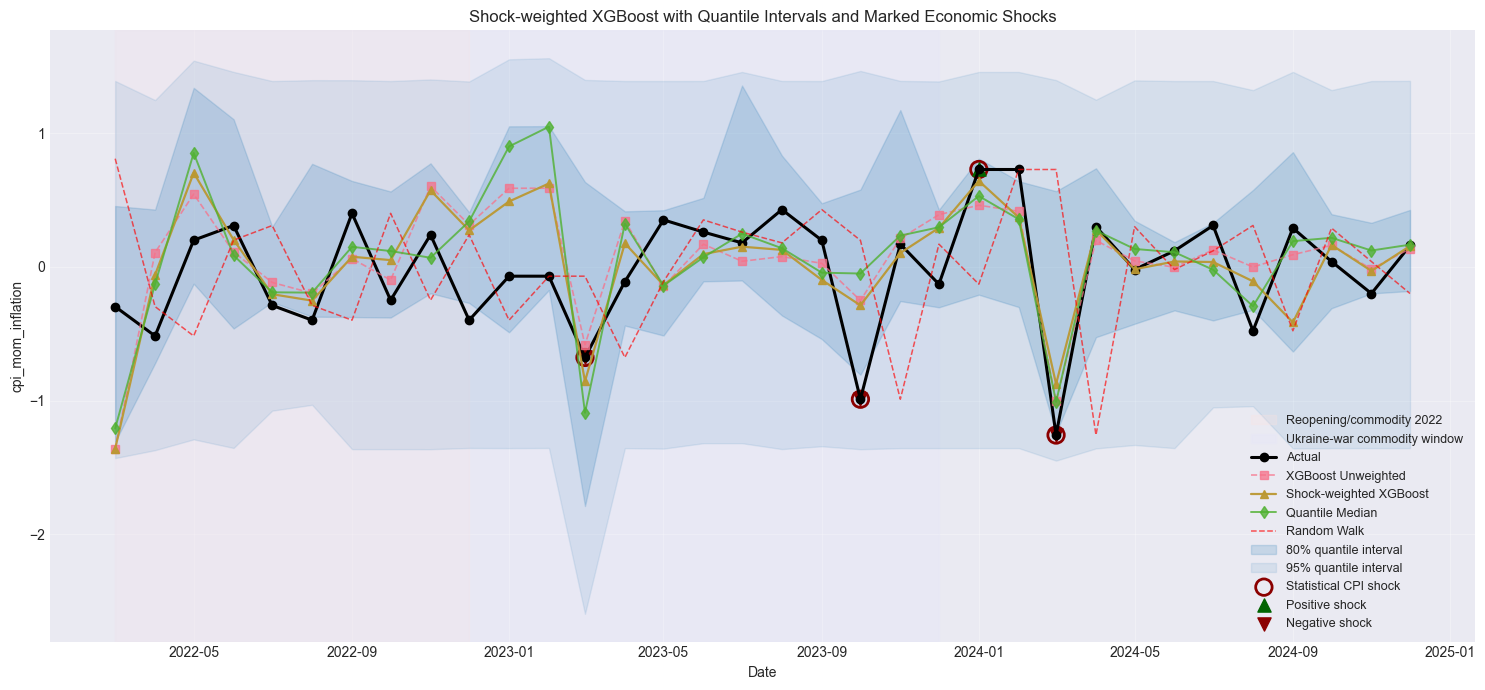

In [14]:
# Mark shock points on test forecast plot.
# Economic shocks are marked by statistical shock points and event windows.

best_point_pred = xgb_shock_pred.copy()
best_point_name = "Shock-weighted XGBoost"

fig, ax = plt.subplots(figsize=(15, 7))

# Event windows on test range
for start, end, color, label in [
    ("2020-03-01", "2021-12-01", "lightgray", "COVID period"),
    ("2022-01-01", "2022-12-01", "mistyrose", "Reopening/commodity 2022"),
    ("2022-02-01", "2023-12-01", "lavender", "Ukraine-war commodity window"),
]:
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    if end_ts >= y_test.index.min() and start_ts <= y_test.index.max():
        ax.axvspan(max(start_ts, y_test.index.min()), min(end_ts, y_test.index.max()), alpha=0.25, color=color, label=label)

ax.plot(y_test.index, y_test.values, "o-", label="Actual", color="black", linewidth=2.2)
ax.plot(y_test.index, xgb_unweighted_pred, "s--", label="XGBoost Unweighted", linewidth=1.2, alpha=0.75)
ax.plot(y_test.index, xgb_shock_pred, "^-", label="Shock-weighted XGBoost", linewidth=1.6, alpha=0.95)
ax.plot(y_test.index, quantile_median_pred, "d-", label="Quantile Median", linewidth=1.4, alpha=0.80)
ax.plot(y_test.index[rw_mask], rw_pred[rw_mask], "--", label="Random Walk", color="red", linewidth=1.1, alpha=0.65)

# Quantile intervals
ax.fill_between(y_test.index, lower80, upper80, alpha=0.18, color="tab:blue", label="80% quantile interval")
ax.fill_between(y_test.index, lower95, upper95, alpha=0.10, color="tab:blue", label="95% quantile interval")

# Statistical shock points
shock_dates = y_test.index[labels_test["stat_shock"].astype(bool)]
ax.scatter(shock_dates, y_test.loc[shock_dates], s=140, facecolors="none", edgecolors="darkred", linewidths=2.0, label="Statistical CPI shock")

# Positive and negative shock markers
pos_dates = y_test.index[labels_test["positive_stat_shock"].astype(bool)]
neg_dates = y_test.index[labels_test["negative_stat_shock"].astype(bool)]
ax.scatter(pos_dates, y_test.loc[pos_dates], marker="^", s=90, color="darkgreen", label="Positive shock")
ax.scatter(neg_dates, y_test.loc[neg_dates], marker="v", s=90, color="darkred", label="Negative shock")

ax.set_title("Shock-weighted XGBoost with Quantile Intervals and Marked Economic Shocks")
ax.set_xlabel("Date")
ax.set_ylabel(target_var)
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shock_weighted_xgb_quantile_forecast_marked_shocks.png"), dpi=150)
plt.show()

In [15]:
# Table of marked shock points in the test set
shock_table = pd.DataFrame({
    "actual": y_test,
    "xgb_unweighted": xgb_unweighted_pred,
    "shock_weighted_xgb": xgb_shock_pred,
    "quantile_median": quantile_median_pred,
    "q10": lower80,
    "q90": upper80,
    "q025": lower95,
    "q975": upper95,
    "inflation_zscore_12": labels_test["inflation_zscore_12"],
    "stat_shock": labels_test["stat_shock"],
    "positive_stat_shock": labels_test["positive_stat_shock"],
    "negative_stat_shock": labels_test["negative_stat_shock"],
}).copy()

# Add event labels for test dates
for col in event_cols:
    shock_table[col] = add_event_features(shock_table.index)[col]

shock_table["abs_error_shock_weighted"] = (shock_table["actual"] - shock_table["shock_weighted_xgb"]).abs()
shock_table["inside_80_interval"] = ((shock_table["actual"] >= shock_table["q10"]) & (shock_table["actual"] <= shock_table["q90"])).astype(int)
shock_table["inside_95_interval"] = ((shock_table["actual"] >= shock_table["q025"]) & (shock_table["actual"] <= shock_table["q975"])).astype(int)

marked_shocks = shock_table[shock_table["stat_shock"] == 1].copy()

print("Marked statistical shock points in test set")
if len(marked_shocks) > 0:
    print(marked_shocks.round(6).to_string())
else:
    print("No statistical shock points in test set under current threshold.")

shock_table.to_csv(os.path.join(OUTPUT_DIR, "test_predictions_with_shock_markers.csv"))
marked_shocks.to_csv(os.path.join(OUTPUT_DIR, "marked_test_shock_points.csv"))

Marked statistical shock points in test set
              actual  xgb_unweighted  shock_weighted_xgb  quantile_median       q10       q90      q025      q975  inflation_zscore_12  stat_shock  positive_stat_shock  negative_stat_shock  gfc_2008_2011  covid_period  reopening_commodity_2022  ukraine_war_commodity  tet_window  school_fee_window  year_end_window  abs_error_shock_weighted  inside_80_interval  inside_95_interval
date                                                                                                                                                                                                                                                                                                                                                                                        
2023-03-01 -0.676954       -0.582176           -0.855144        -1.091020 -1.787591  0.634381 -2.592975  1.397227            -1.864876         1.0                  0.0                  1.0      

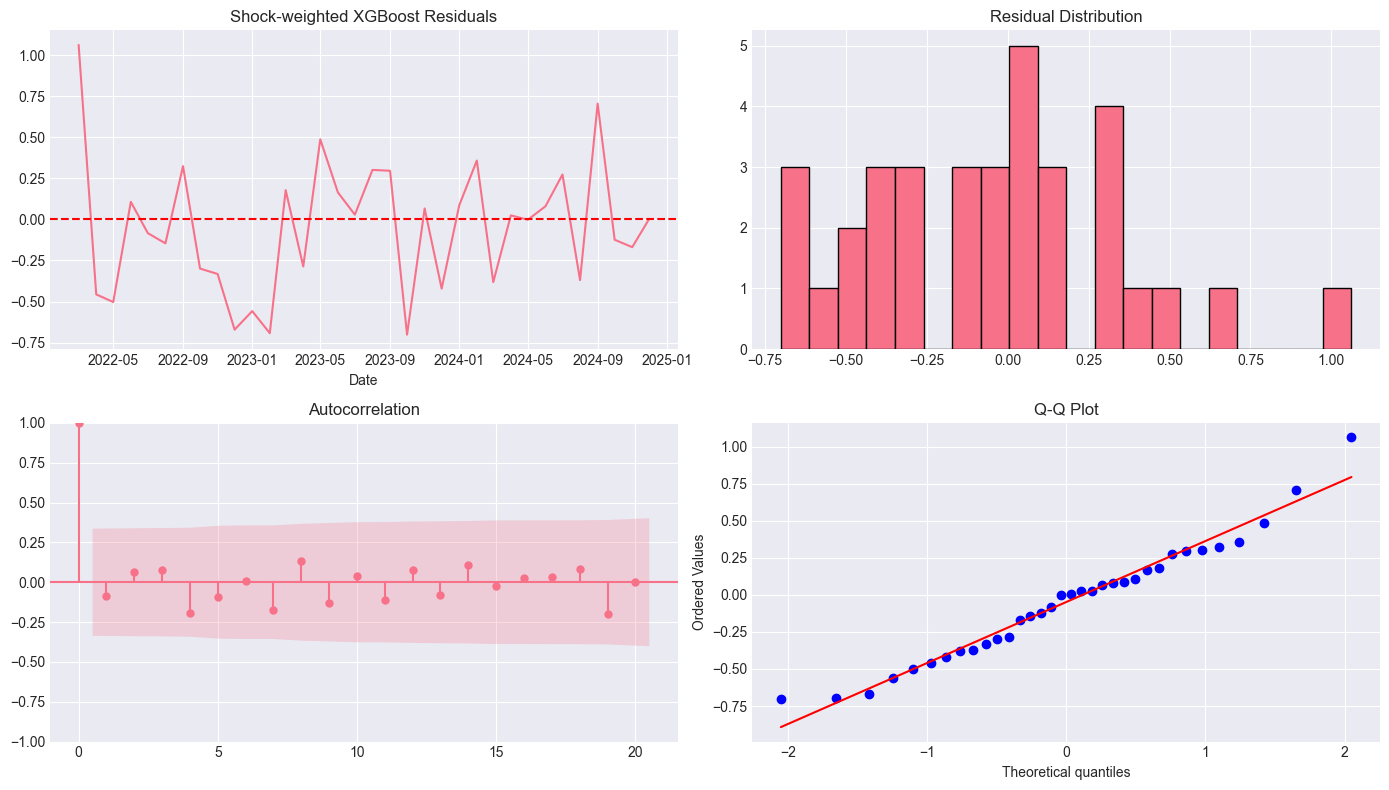

Residual mean: -0.048611
Residual std:  0.397433
Jarque-Bera p-value: 0.544371


In [16]:
# Residual diagnostics for shock-weighted XGBoost
residuals = y_test.values - xgb_shock_pred.values
max_lags = min(20, len(residuals) - 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(y_test.index, residuals)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Shock-weighted XGBoost Residuals")
axes[0, 0].set_xlabel("Date")

axes[0, 1].hist(residuals, bins=20, edgecolor="black")
axes[0, 1].set_title("Residual Distribution")

plot_acf(residuals, lags=max_lags, ax=axes[1, 0])
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shock_weighted_xgb_residual_diagnostics.png"), dpi=150)
plt.show()

jb_stat, jb_p = jarque_bera(residuals)
print(f"Residual mean: {np.mean(residuals):.6f}")
print(f"Residual std:  {np.std(residuals):.6f}")
print(f"Jarque-Bera p-value: {jb_p:.6f}")

Running SHAP for final shock-weighted XGBoost...
Top 25 SHAP features on test set
                       feature  mean_abs_shap
                     month_sin       0.256513
       cpi_mom_inflation_lag24       0.098434
                      dlog_wti       0.079658
          dlog_USDVND_abs_lag1       0.044472
        cpi_mom_inflation_lag2       0.040388
       cpi_mom_inflation_lag12       0.039091
       cpi_mom_inflation_lag23       0.036400
 cpi_mom_inflation_roll_std_12       0.036139
 cpi_mom_inflation_roll_mean_6       0.032461
 cpi_mom_inflation_roll_mean_3       0.030712
       cpi_mom_inflation_lag19       0.029927
cpi_mom_inflation_roll_mean_12       0.028356
      dlog_USDVND_roll_mean_12       0.027740
                  dlog_VNINDEX       0.027470
       dlog_VNINDEX_roll_std_3       0.027452
                dlog_wti_lag12       0.025982
              dlog_broad_money       0.023262
       dlog_USDVND_roll_mean_6       0.023017
         dlog_broad_money_lag3       0.02142

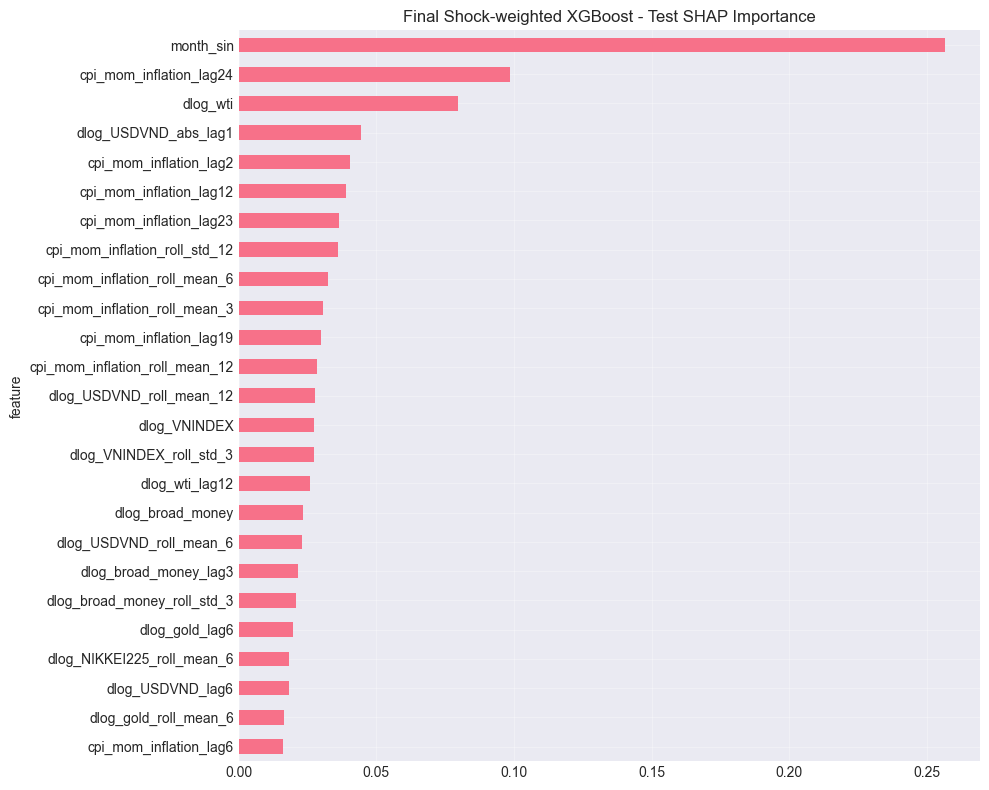

In [17]:
# SHAP explainability for final shock-weighted XGBoost
if HAS_SHAP and HAS_XGB:
    print("Running SHAP for final shock-weighted XGBoost...")
    explainer_final = shap.TreeExplainer(xgb_shock_weighted)
    shap_values_test = explainer_final.shap_values(X_test_sel)

    shap_importance_test = pd.DataFrame({
        "feature": X_test_sel.columns,
        "mean_abs_shap": np.abs(shap_values_test).mean(axis=0)
    }).sort_values("mean_abs_shap", ascending=False)

    print("Top 25 SHAP features on test set")
    print(shap_importance_test.head(25).to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    shap_importance_test.head(25).iloc[::-1].plot(x="feature", y="mean_abs_shap", kind="barh", ax=ax, legend=False)
    ax.set_title("Final Shock-weighted XGBoost - Test SHAP Importance")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "final_shock_weighted_xgb_shap_importance.png"), dpi=150)
    plt.show()

    shap_importance_test.to_csv(os.path.join(OUTPUT_DIR, "final_shock_weighted_xgb_shap_importance.csv"), index=False)
else:
    print("SHAP final analysis skipped.")

In [18]:
print("\n" + "="*80)
print("SHOCK-WEIGHTED XGBOOST + QUANTILE INTERVALS SUMMARY")
print("="*80)
print(f"Target: {target_var}")
print(f"Use current exogenous variables: {USE_CURRENT_EXOG}")
print(f"Supervised observations: {len(X)}")
print(f"Selected features: {len(selected_features)}")
print(f"Train period: {X_train.index.min().date()} to {X_train.index.max().date()}")
print(f"Validation period: {X_val.index.min().date()} to {X_val.index.max().date()}")
print(f"Test period: {X_test.index.min().date()} to {X_test.index.max().date()}")
print(f"Train shocks: {int(labels_train['stat_shock'].sum())}")
print(f"Validation shocks: {int(labels_val['stat_shock'].sum())}")
print(f"Test shocks: {int(labels_test['stat_shock'].sum())}")
print(f"Best shock weight: {best_shock_weight}")
print("\nOverall comparison:")
print(results_df.to_string(index=False))
print("\nShock vs non-shock comparison:")
print(shock_results_df.to_string(index=False))
print("\nQuantile interval diagnostics:")
print(interval_df.to_string(index=False))
print("\nMethod note: shock-weighted XGBoost increases the training weight of statistically defined CPI shock months. Quantile models provide uncertainty intervals, which are especially useful when point forecasts under-react to extreme CPI movements.")
print("="*80)


SHOCK-WEIGHTED XGBOOST + QUANTILE INTERVALS SUMMARY
Target: cpi_mom_inflation
Use current exogenous variables: True
Supervised observations: 335
Selected features: 40
Train period: 1997-02-01 to 2019-05-01
Validation period: 2019-06-01 to 2022-02-01
Test period: 2022-03-01 to 2024-12-01
Train shocks: 45
Validation shocks: 6
Test shocks: 4
Best shock weight: 3.0

Overall comparison:
                 Model     RMSE      MAE        R2  Model_vs_RW  Model_vs_Mean
Shock-weighted XGBoost 0.400395 0.316074  0.138016     0.573572       0.928431
    XGBoost Unweighted 0.400941 0.320345  0.135662     0.574354       0.929698
         Mean Baseline 0.431260 0.341284  0.000000     0.617786       1.000000
   Quantile Median HGB 0.449427 0.346329 -0.086025     0.643811       1.042125
           Random Walk 0.698073 0.533684       NaN     1.000000       1.618683

Shock vs non-shock comparison:
                 Model  Shock_N  Shock_RMSE  Shock_MAE  NonShock_N  NonShock_RMSE  NonShock_MAE
    XGBoost 